# Poisoning Experiment — Accuracy vs Poison Rate (full grid)
Sweep `poison_rate` ∈ {0, 0.25, 0.5, 0.75, 1.0} × 3 prompt types × 2 models con **k=5 fisso**.

Misura come la factual accuracy degrada al crescere del poisoning e se prompt type o modello
offrono robustezza differenziale (Strategy A — Zhou et al. 2024 §Robustness).

**Imposta `DRY_RUN = True` per validare il wiring (~90 chiamate), `False` per l'esperimento completo (~1.500 chiamate).**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DRY_RUN = False  # set True for a quick validation run (N=10)

# Poisoning strategy: "opposite_label" (Strategy A) or "llm_negation" (Strategy B).
# Strategy B uses the same LLM as the model-under-test to generate direct
# contradictions of each gold passage; results are cached so re-runs are free.
STRATEGY        = cfg["poisoning"].get("strategy", "opposite_label")

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPES    = ["standard", "chain_of_thought", "vigilant"]
TEMPERATURE     = cfg["models"]["temperature"]
POISON_RATES    = [0.0, 0.25, 0.5, 0.75, 1.0]
N_EXAMPLES      = 10 if DRY_RUN else cfg["evaluation"]["n_examples"]

total_calls = len(POISON_RATES) * len(PROMPT_TYPES) * len(MODELS) * N_EXAMPLES
print(f"DRY_RUN={DRY_RUN}  n_examples={N_EXAMPLES}  strategy={STRATEGY}")
print(f"Grid: {len(POISON_RATES)} rates × {len(PROMPT_TYPES)} prompts × {len(MODELS)} models")
print(f"Estimated API calls: {total_calls}")

DRY_RUN=False  n_examples=50  strategy=opposite_label
Grid: 5 rates × 3 prompts × 5 models
Estimated API calls: 3750


In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples = all_examples[:N_EXAMPLES]
print(f"Total loaded: {len(all_examples):,}  |  Using: {len(examples)}")

Total loaded: 15,935  |  Using: 50


In [3]:
def build_llm(model: str):
    return HuggingFaceClient(model=model, temperature=TEMPERATURE, cache_dir=LLM_CACHE)

In [4]:
def run_poisoning_sweep(examples, poison_rates, prompt_types, k, embedder, llm,
                        distractor_pool, seed, strategy="opposite_label"):
    """Sweep poison_rates x prompt_types for a single open LLM client.

    Returns a list of row dicts (model, poison_rate, prompt_type, + metrics).
    embedder and llm must already be open (called within their context managers).
    When strategy='llm_negation' the same llm is used to generate adversarial
    negations of each gold passage (cached on disk).
    """
    rows = []
    model_name = llm._model
    for poison_rate in poison_rates:
        poisoned = (
            poison_dataset(
                examples, poison_rate=poison_rate, seed=seed,
                strategy=strategy, llm=llm,
            )
            if poison_rate > 0.0
            else examples
        )
        for prompt_type in prompt_types:
            retriever = Retriever(embedder=embedder, k=k)
            metrics = run_scorer(
                examples=poisoned,
                retriever=retriever,
                llm=llm,
                prompt_type=prompt_type,
                distractor_pool_size=distractor_pool,
                seed=seed,
                self_consistency_runs=1,
            )
            rows.append({"model": model_name, "poison_rate": poison_rate,
                         "prompt_type": prompt_type, "strategy": strategy, **metrics})
            print(
                f"  {model_name.split('-')[0]:6s}  rate={poison_rate:.2f}  "
                f"prompt={prompt_type:15s}  acc={metrics['accuracy']:.3f}"
            )
    return rows

In [5]:
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE, device="cpu")
all_rows = []

print(f"Starting full grid sweep (strategy={STRATEGY})...")
for model_name in MODELS:
    print(f"\n--- Model: {model_name} ---")
    llm = build_llm(model_name)
    with llm:
        all_rows.extend(
            run_poisoning_sweep(
                examples=examples,
                poison_rates=POISON_RATES,
                prompt_types=PROMPT_TYPES,
                k=K,
                embedder=embedder,
                llm=llm,
                distractor_pool=DISTRACTOR_POOL,
                seed=SEED,
                strategy=STRATEGY,
            )
        )

embedder.close()
results = pd.DataFrame(all_rows)
print(f"\nSweep done. {len(results)} conditions collected.")
results

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Starting full grid sweep (strategy=opposite_label)...

--- Model: Qwen/Qwen2.5-1.5B-Instruct ---
  Qwen/Qwen2.5  rate=0.00  prompt=standard         acc=0.480
  Qwen/Qwen2.5  rate=0.00  prompt=chain_of_thought  acc=0.560
  Qwen/Qwen2.5  rate=0.00  prompt=vigilant         acc=0.340
  Qwen/Qwen2.5  rate=0.25  prompt=standard         acc=0.440
  Qwen/Qwen2.5  rate=0.25  prompt=chain_of_thought  acc=0.600
  Qwen/Qwen2.5  rate=0.25  prompt=vigilant         acc=0.320
  Qwen/Qwen2.5  rate=0.50  prompt=standard         acc=0.440
  Qwen/Qwen2.5  rate=0.50  prompt=chain_of_thought  acc=0.500
  Qwen/Qwen2.5  rate=0.50  prompt=vigilant         acc=0.340
  Qwen/Qwen2.5  rate=0.75  prompt=standard         acc=0.500
  Qwen/Qwen2.5  rate=0.75  prompt=chain_of_thought  acc=0.440
  Qwen/Qwen2.5  rate=0.75  prompt=vigilant         acc=0.320
  Qwen/Qwen2.5  rate=1.00  prompt=standard         acc=0.360
  Qwen/Qwen2.5  rate=1.00  prompt=chain_of_thought  acc=0.480
  Qwen/Qwen2.5  rate=1.00  prompt=vigilant  

,model,poison_rate,prompt_type,strategy,accuracy,macro_f1,hallucination_rate,precision_at_k,contradiction_detection_rate
0,Qwen/Qwen2.5-1.5B-Instruct,0.00,standard,opposite_label,0.48,0.464188,0.235294,0.208,NaN
1,Qwen/Qwen2.5-1.5B-Instruct,0.00,chain_of_thought,opposite_label,0.56,0.447619,0.117647,0.208,NaN
2,Qwen/Qwen2.5-1.5B-Instruct,0.00,vigilant,opposite_label,0.34,0.171717,0.000000,0.208,0.00
3,Qwen/Qwen2.5-1.5B-Instruct,0.25,standard,opposite_label,0.44,0.372975,0.176471,0.156,NaN
4,Qwen/Qwen2.5-1.5B-Instruct,0.25,chain_of_thought,opposite_label,0.60,0.502623,0.176471,0.156,NaN
...,...,...,...,...,...,...,...,...,...
70,meta-llama/Llama-3.2-3B-Instruct,0.75,chain_of_thought,opposite_label,0.46,0.430694,0.352941,0.064,NaN
71,meta-llama/Llama-3.2-3B-Instruct,0.75,vigilant,opposite_label,0.38,0.312891,0.352941,0.064,0.00
72,meta-llama/Llama-3.2-3B-Instruct,1.00,standard,opposite_label,0.42,0.301106,0.000000,0.000,NaN
73,meta-llama/Llama-3.2-3B-Instruct,1.00,chain_of_thought,opposite_label,0.44,0.429149,0.352941,0.000,NaN


Saved → figures/03_accuracy_vs_poison_rate.png


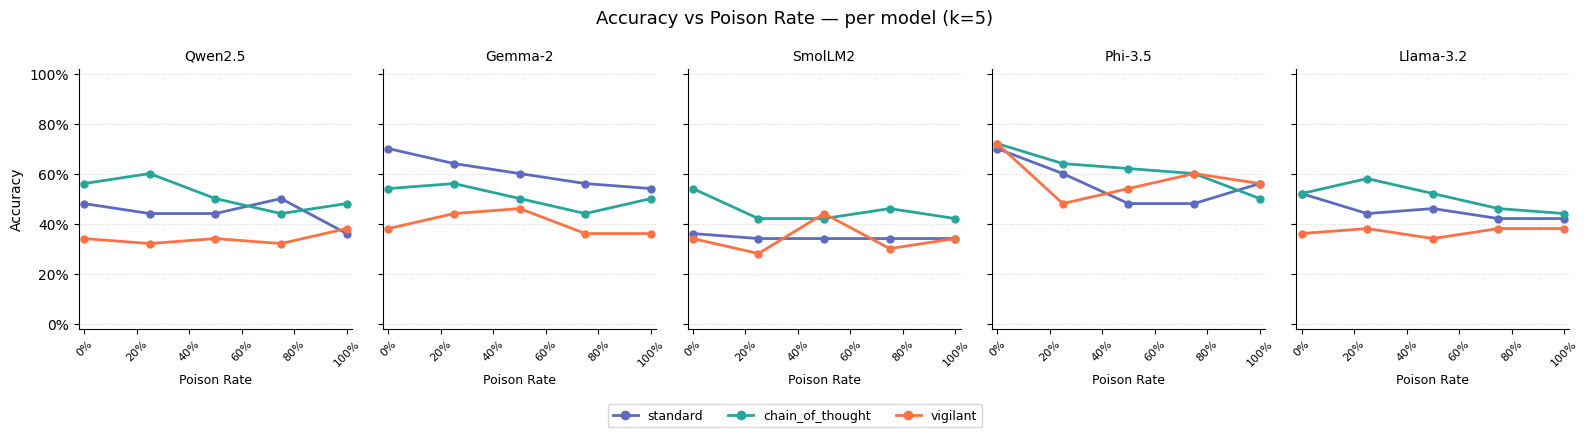

In [6]:
PROMPT_COLORS = {
    "standard":         "#5C6BC0",
    "chain_of_thought": "#26A69A",
    "vigilant":         "#FF7043",
}
MODEL_LABELS = {
    "Qwen/Qwen2.5-1.5B-Instruct":           "Qwen2.5",
    "google/gemma-2-2b-it":                  "Gemma-2",
    "HuggingFaceTB/SmolLM2-1.7B-Instruct":  "SmolLM2",
    "microsoft/Phi-3.5-mini-instruct":       "Phi-3.5",
    "meta-llama/Llama-3.2-3B-Instruct":      "Llama-3.2",
}

fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)

for ax, model in zip(axes, MODELS):
    for prompt in PROMPT_TYPES:
        sub = results[
            (results["model"] == model) & (results["prompt_type"] == prompt)
        ].sort_values("poison_rate")
        ax.plot(
            sub["poison_rate"], sub["accuracy"],
            marker="o", linewidth=2, markersize=5,
            color=PROMPT_COLORS[prompt], label=prompt,
        )
    ax.set_title(MODEL_LABELS[model], fontsize=10, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_xlabel("Poison Rate", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Accuracy")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [
    plt.Line2D([0], [0], color=PROMPT_COLORS[p], marker="o", linewidth=2, label=p)
    for p in PROMPT_TYPES
]
fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(f"Accuracy vs Poison Rate — per model (k={K})", fontsize=13)

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/03_accuracy_vs_poison_rate.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/03_accuracy_vs_poison_rate.png")
plt.show()

Saved → figures/03_hallucination_vs_poison_rate.png


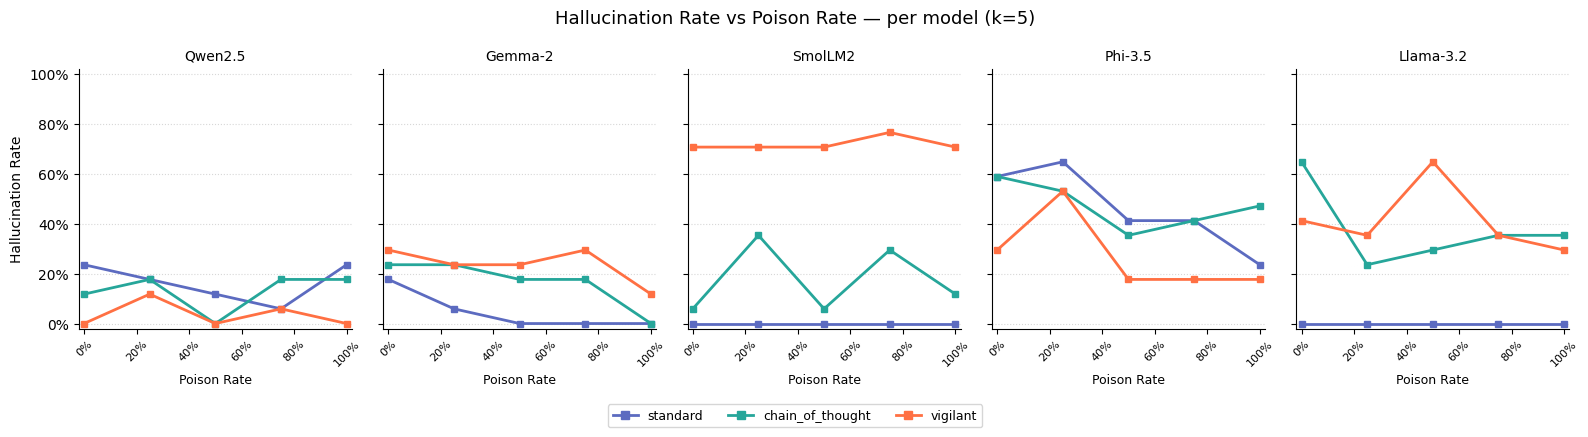

In [7]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)

for ax, model in zip(axes, MODELS):
    for prompt in PROMPT_TYPES:
        sub = results[
            (results["model"] == model) & (results["prompt_type"] == prompt)
        ].sort_values("poison_rate")
        ax.plot(
            sub["poison_rate"], sub["hallucination_rate"],
            marker="s", linewidth=2, markersize=5,
            color=PROMPT_COLORS[prompt], label=prompt,
        )
    ax.set_title(MODEL_LABELS[model], fontsize=10, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_xlabel("Poison Rate", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Hallucination Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [
    plt.Line2D([0], [0], color=PROMPT_COLORS[p], marker="s", linewidth=2, label=p)
    for p in PROMPT_TYPES
]
fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(f"Hallucination Rate vs Poison Rate — per model (k={K})", fontsize=13)

plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/03_hallucination_vs_poison_rate.png", dpi=150, bbox_inches="tight")
    print("Saved → figures/03_hallucination_vs_poison_rate.png")
plt.show()

In [8]:
pivot = results.pivot_table(
    index=["model", "prompt_type"],
    columns="poison_rate",
    values="accuracy",
)
pivot.columns = [f"{c:.0%}" for c in pivot.columns]
pivot.index = pivot.index.map(lambda x: (MODEL_LABELS[x[0]], x[1]))
print("=== Accuracy pivot (rows: model × prompt, cols: poison_rate) ===")
print(pivot.to_string(float_format="{:.3f}".format))
print("\nKey takeaway: rows with least degradation = most robust condition.")

=== Accuracy pivot (rows: model × prompt, cols: poison_rate) ===
                              0%   25%   50%   75%  100%
model     prompt_type                                   
SmolLM2   chain_of_thought 0.540 0.420 0.420 0.460 0.420
          standard         0.360 0.340 0.340 0.340 0.340
          vigilant         0.340 0.280 0.440 0.300 0.340
Qwen2.5   chain_of_thought 0.560 0.600 0.500 0.440 0.480
          standard         0.480 0.440 0.440 0.500 0.360
          vigilant         0.340 0.320 0.340 0.320 0.380
Gemma-2   chain_of_thought 0.540 0.560 0.500 0.440 0.500
          standard         0.700 0.640 0.600 0.560 0.540
          vigilant         0.380 0.440 0.460 0.360 0.360
Llama-3.2 chain_of_thought 0.520 0.580 0.520 0.460 0.440
          standard         0.520 0.440 0.460 0.420 0.420
          vigilant         0.360 0.380 0.340 0.380 0.380
Phi-3.5   chain_of_thought 0.720 0.640 0.620 0.600 0.500
          standard         0.700 0.600 0.480 0.480 0.560
          vigilant     

---
## Qualitative Failure Analysis

Surface concrete examples of scientifically interesting failures from the cached poisoning experiment results.  
**No new LLM calls** — every `llm.complete()` call below hits the disk cache.

In [9]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import prepare_cases, resolve
from src.evaluation.failures import (
    classify_failure,
    find_failure_examples,
    find_vigilant_contrast_examples,
)

# Use a single model + a small subset for qualitative analysis
QUAL_MODEL   = MODELS[0]   # first model in the config
QUAL_N       = min(50, N_EXAMPLES)  # enough examples to find interesting cases

all_examples = load_fever('../' + cfg['dataset']['fever_dev'])
qual_examples = all_examples[:QUAL_N]

emb = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE, device='cpu')
llm = HuggingFaceClient(model=QUAL_MODEL, temperature=TEMPERATURE, cache_dir=LLM_CACHE)

# Prepare per-prompt cases at two poison rates
with llm:
    # ---- 50% poison rate — standard ----
    poisoned_50 = poison_dataset(qual_examples, poison_rate=0.5, seed=SEED)
    ret_std  = Retriever(embedder=emb, k=K)
    ret_vig  = Retriever(embedder=emb, k=K)
    ret_high = Retriever(embedder=emb, k=K)
    cases_std  = prepare_cases(poisoned_50, ret_std,  prompt_type='standard',
                               distractor_pool_size=DISTRACTOR_POOL, seed=SEED)
    cases_vig  = prepare_cases(poisoned_50, ret_vig,  prompt_type='vigilant',
                               distractor_pool_size=DISTRACTOR_POOL, seed=SEED)
    results_std  = resolve(cases_std, llm)
    results_vig  = resolve(cases_vig, llm)
    # ---- 100% poison rate — standard (NEI collapse) ----
    poisoned_100 = poison_dataset(qual_examples, poison_rate=1.0, seed=SEED)
    ret_full = Retriever(embedder=emb, k=K)
    cases_full   = prepare_cases(poisoned_100, ret_full, prompt_type='standard',
                                 distractor_pool_size=DISTRACTOR_POOL, seed=SEED)
    results_full = resolve(cases_full, llm)

emb.close()
print(f'Loaded {len(cases_std)} cases for qualitative analysis (model={QUAL_MODEL.split("/")[-1]})')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded 50 cases for qualitative analysis (model=Qwen2.5-1.5B-Instruct)


In [10]:
PROMPT_COLORS_HEX = {'standard': '#5C6BC0', 'chain_of_thought': '#26A69A', 'vigilant': '#FF7043'}

def display_example(case, result, annotation, title=None):
    """Pretty-print a single failure example."""
    if title:
        print(f'\n{'='*70}')
        print(f'  {title}')
        print(f'{'='*70}')
    gold_set = set(case.gold_passages)
    print(f'CLAIM    : {case.claim}')
    print(f'GOLD     : {case.gold_label}')
    print(f'PREDICTED: {result.predicted_label}')
    print()
    print('RETRIEVED PASSAGES:')
    for i, p in enumerate(case.passages, 1):
        tag = '[GOLD]    ' if p in gold_set else '[NON-GOLD]'
        snippet = p[:120].replace('\n', ' ')
        print(f'  {i}. {tag} {snippet}...' if len(p) > 120 else f'  {i}. {tag} {snippet}')
    print()
    print(f'ANNOTATION: {annotation}')
    print()

### Category 1 — Convinced by Minority Poison

The model predicts incorrectly despite a majority of retrieved passages being gold evidence.  
A single adversarially modified passage outweighs several correct ones — a sign that the model is over-sensitive to conflicting context rather than counting evidence.

In [11]:
minority_examples = find_failure_examples(
    cases_std, results_std, 'convinced_by_minority_poison', max_examples=2
)

if minority_examples:
    for i, (case, result) in enumerate(minority_examples, 1):
        gold_set = set(case.gold_passages)
        n_non_gold = sum(1 for p in case.passages if p not in gold_set)
        annotation = (
            f'{n_non_gold}/{len(case.passages)} retrieved passages were non-gold, '
            f'yet the model predicted {result.predicted_label!r} instead of '
            f'{case.gold_label!r}. The minority non-gold passage(s) dominated '
            f'the model\'s reasoning over {len(case.passages) - n_non_gold} gold passages.'
        )
        display_example(case, result, annotation, title=f'Example C1.{i}')
else:
    print('No convinced-by-minority examples found in this subset — try increasing QUAL_N.')

No convinced-by-minority examples found in this subset — try increasing QUAL_N.


### Category 2 — Vigilant Prompt: Helps vs. Does Not Help

Comparing standard vs. vigilant prompting on the same claim and retrieved passages.  
When vigilant helps, explicit reasoning instructions decouple generation accuracy from retrieval quality.  
When vigilant fails, the poisoning is strong enough that even cautious instructions cannot recover the correct label.

In [12]:
helped_examples = find_vigilant_contrast_examples(
    cases_std, results_std, results_vig, kind='helped', max_examples=1
)
failed_examples = find_vigilant_contrast_examples(
    cases_std, results_std, results_vig, kind='failed', max_examples=1
)

for label, examples in [('VIGILANT HELPS', helped_examples),
                         ('VIGILANT DOES NOT HELP', failed_examples)]:
    if examples:
        case, sr, vr = examples[0]
        gold_set = set(case.gold_passages)
        n_non_gold = sum(1 for p in case.passages if p not in gold_set)
        annotation = (
            f'[{label}] '
            f'Standard predicted {sr.predicted_label!r}, '
            f'Vigilant predicted {vr.predicted_label!r} '
            f'(gold: {case.gold_label!r}). '
            f'{n_non_gold}/{len(case.passages)} retrieved passages are non-gold.'
        )
        display_example(case, sr, annotation, title=label)
    else:
        print(f'{label}: no examples found in this subset.')


  VIGILANT HELPS
CLAIM    : Eric Church has written over 100 songs.
GOLD     : NOT ENOUGH INFO
PREDICTED: SUPPORTS

RETRIEVED PASSAGES:
  1. [GOLD]     He has also written and produced songs for Tim McGraw , Rascal Flatts , Kacey Musgraves , Toby Keith , Ne-Yo , John Lege...
  2. [NON-GOLD] Huckabee is the author of several best-selling books , an ordained Southern Baptist minister noted for his evangelical v...
  3. [NON-GOLD] Huckabee is the author of several best-selling books , an ordained Southern Baptist minister noted for his evangelical v...
  4. [NON-GOLD] Highway to Heaven is an American television drama series which ran on NBC from 1984 to 1989 .
  5. [NON-GOLD] Caplan also starred in television shows The Class , True Blood , and Party Down .

ANNOTATION: [VIGILANT HELPS] Standard predicted 'SUPPORTS', Vigilant predicted 'NOT ENOUGH INFO' (gold: 'NOT ENOUGH INFO'). 4/5 retrieved passages are non-gold.


  VIGILANT DOES NOT HELP
CLAIM    : Jackie (2016 film) was directed by 

### Category 3 — NEI Collapse Under High Poison Rate

At `poison_rate=1.0` no gold passages are retrieved (precision@k=0).  
With no supporting evidence, the model defaults to NOT ENOUGH INFO even for claims that are definitively SUPPORTS or REFUTES — it prefers abstaining over relying on parametric knowledge alone.

In [13]:
nei_examples = find_failure_examples(
    cases_full, results_full, 'nei_collapse', max_examples=2
)

if nei_examples:
    for i, (case, result) in enumerate(nei_examples, 1):
        annotation = (
            f'At 100% poison rate all {len(case.passages)} retrieved passages are '
            f'non-gold. The model collapses to {result.predicted_label!r} despite '
            f'the claim being definitively {case.gold_label!r}.'
        )
        display_example(case, result, annotation, title=f'Example C3.{i}')
else:
    print('No NEI-collapse examples found — try increasing QUAL_N.')


  Example C3.1
CLAIM    : Jackie (2016 film) was directed by Peter Jackson.
GOLD     : REFUTES
PREDICTED: NOT ENOUGH INFO

RETRIEVED PASSAGES:
  1. [NON-GOLD] It is a remake of the 1972 Fist of Fury , which starred Bruce Lee as the lead character .
  2. [NON-GOLD] The film centers on Stanley Jobson , an ex-con and computer hacker who is targeted for recruitment into a bank robbery c...
  3. [NON-GOLD] The film centers on Stanley Jobson , an ex-con and computer hacker who is targeted for recruitment into a bank robbery c...
  4. [NON-GOLD] The film won eight Goya Awards , including awards for Best Film and Best Director .
  5. [NON-GOLD] She had subsequent roles in the films Delivery Man -LRB- 2013 -RRB- and Ask Me Anything -LRB- 2014 -RRB- , for which she...

ANNOTATION: At 100% poison rate all 5 retrieved passages are non-gold. The model collapses to 'NOT ENOUGH INFO' despite the claim being definitively 'REFUTES'.


  Example C3.2
CLAIM    : The CONCACAF Champions League is organize

### Summary

| Category | Key insight |
| --- | --- |
| Convinced by minority poison | A single adversarially crafted passage can override multiple gold passages, revealing the model's lack of evidence-counting. |
| Vigilant helps | Explicit reasoning instructions give the model a scaffold to discount conflicting context, partially decoupling generation accuracy from retrieval quality. |
| Vigilant fails | When poisoned passages dominate (majority non-gold), even vigilant prompting cannot recover the correct label — retrieval quality sets the floor. |
| NEI collapse | At 100% poison rate the model abstains rather than rely on parametric knowledge, trading hallucination risk for false abstention. |